In [23]:
# =============================================================
# PROJECT: Last Mile Logistics Auditor
# Dataset: Olist Brazilian E-Commerce
# =============================================================
# EXECUTIVE SUMMARY:
# Analysis of 99,441 orders reveals that ~6.8% of deliveries were late. 
# Northeastern states (AL, MA, SE) suffer the highest late rates (15-21%), confirming a regional problem tied to distance from distribution centers.
# Late deliveries directly correlate with poor reviews — on-time orders average 4.29/5 vs 1.74/5 for super-late orders. 
# Peak delay periods occur in Q1 (Jan-March), suggesting post-holiday logistics strain.
# =============================================================

In [24]:
import subprocess
subprocess.run([
    "jupyter", "nbconvert", "--to", "html", "Logistics Auditor.ipynb"
])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'Logistics Auditor.ipynb'], returncode=0)

In [1]:
pip install pandas matplotlib seaborn plotly folium notebook

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import pandas as pd

print(os.getcwd())

orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
translations = pd.read_csv("product_category_name_translation.csv")

print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Translations:", translations.shape)

C:\Users\USER PC\Downloads\Logistic Auditor
Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translations: (71, 2)


In [14]:
##Story 1: Join the tables

# Join Reviews to Orders on order_id
master = orders.merge(reviews, on="order_id", how="left")

# Join Customers to Orders on customer_id
master = master.merge(customers, on="customer_id", how="left")

# Check shape - should still be ~99,441 rows (no duplicates)
print("Master dataset shape:", master.shape)
print("\nColumns:", master.columns.tolist())

Master dataset shape: (99992, 18)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [10]:
# Keep only the latest review per order to avoid duplicates
reviews_deduped = reviews.sort_values("review_creation_date").drop_duplicates(
    subset="order_id", keep="last"
)

# Redo the joins
master = orders.merge(reviews_deduped, on="order_id", how="left")
master = master.merge(customers, on="customer_id", how="left")

print("Master dataset shape:", master.shape)
print("Expected: ~99,441 rows")

Master dataset shape: (99441, 18)
Expected: ~99,441 rows


In [16]:
##Story 2: The Delay Calculator

# Convert date columns to datetime
master["order_estimated_delivery_date"] = pd.to_datetime(master["order_estimated_delivery_date"])
master["order_delivered_customer_date"] = pd.to_datetime(master["order_delivered_customer_date"])

# Calculate delay (positive = late, negative = early)
master["days_difference"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.days

# Classify delivery status
def classify_delivery(days):
    if pd.isna(days):
        return "Undelivered"
    elif days <= 0:
        return "On Time"
    elif days <= 5:
        return "Late"
    else:
        return "Super Late"

master["delivery_status"] = master["days_difference"].apply(classify_delivery)

# Exclude undelivered orders for analysis
delivered = master[master["delivery_status"] != "Undelivered"]

# Summary
print(master["delivery_status"].value_counts())
print("\nDelivered orders:", len(delivered))

delivery_status
On Time        90442
Super Late      3786
Undelivered     2987
Late            2777
Name: count, dtype: int64

Delivered orders: 97005


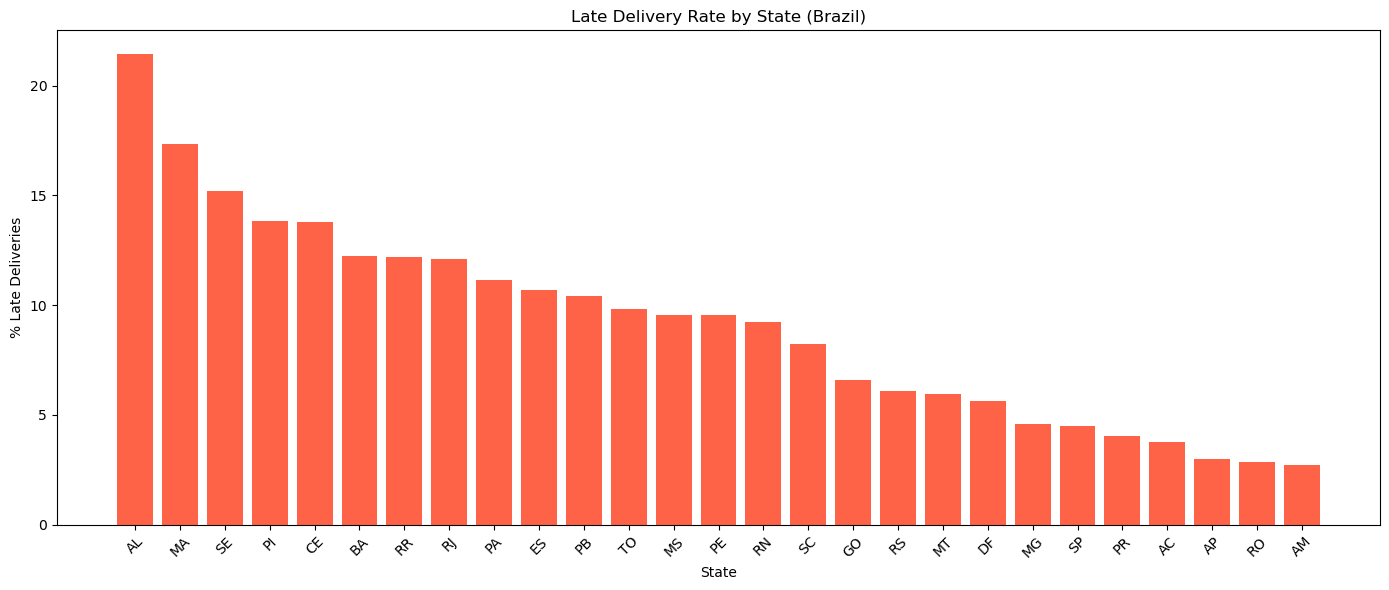

   customer_state  total_orders  late_orders  late_percentage
1              AL           401           86            21.45
9              MA           721          125            17.34
24             SE           335           51            15.22
16             PI           477           66            13.84
5              CE          1282          177            13.81
4              BA          3273          400            12.22
21             RR            41            5            12.20
18             RJ         12423         1503            12.10
13             PA           952          106            11.13
7              ES          2004          214            10.68


In [17]:
## Story 3: Geographic Heatmap

import matplotlib.pyplot as plt

# Calculate late orders per state
state_stats = delivered.groupby("customer_state").agg(
    total_orders=("order_id", "count"),
    late_orders=("delivery_status", lambda x: (x != "On Time").sum())
).reset_index()

state_stats["late_percentage"] = (
    state_stats["late_orders"] / state_stats["total_orders"] * 100
).round(2)

# Sort by worst performing states
state_stats = state_stats.sort_values("late_percentage", ascending=False)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(state_stats["customer_state"], state_stats["late_percentage"], color="tomato")
plt.xlabel("State")
plt.ylabel("% Late Deliveries")
plt.title("Late Delivery Rate by State (Brazil)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("late_by_state.png")
plt.show()

print(state_stats.head(10))

Average Review Score by Delivery Status:
delivery_status
Late          2.99
On Time       4.29
Super Late    1.74
Name: review_score, dtype: float64


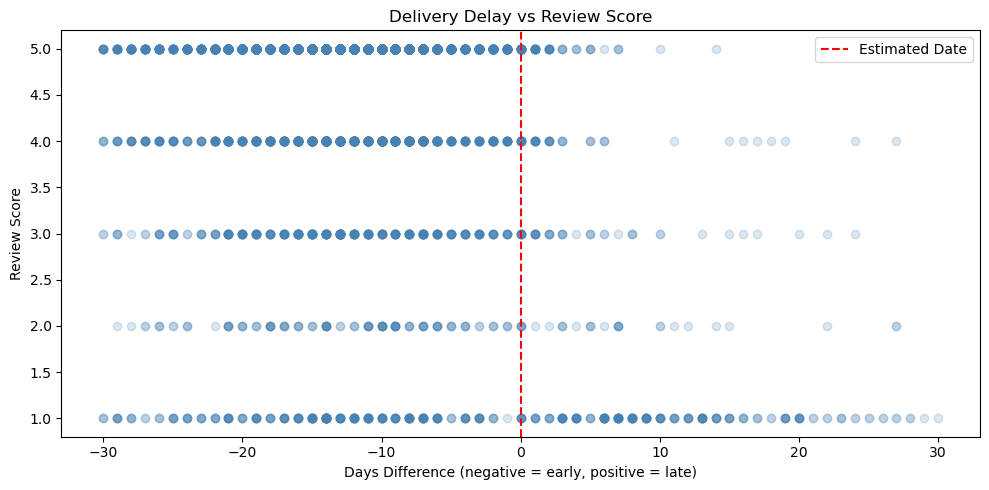

In [18]:
##Story 4: Sentiment Correlation

# Average review score by delivery status
sentiment = delivered.groupby("delivery_status")["review_score"].mean().round(2)
print("Average Review Score by Delivery Status:")
print(sentiment)

# Scatter plot: delay days vs review score
import matplotlib.pyplot as plt

# Sample to avoid overplotting
sample = delivered[delivered["days_difference"].between(-30, 30)].sample(5000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample["days_difference"], sample["review_score"], alpha=0.2, color="steelblue")
plt.axvline(0, color="red", linestyle="--", label="Estimated Date")
plt.xlabel("Days Difference (negative = early, positive = late)")
plt.ylabel("Review Score")
plt.title("Delivery Delay vs Review Score")
plt.legend()
plt.tight_layout()
plt.savefig("sentiment_correlation.png")
plt.show()


In [19]:
##Story 5: Translate product categories

# Merge products with translations
products_translated = products.merge(
    translations, 
    on="product_category_name", 
    how="left"
)

# Merge products into master dataset via order_items
order_items = pd.read_csv("olist_order_items_dataset.csv")

master_full = master.merge(order_items[["order_id", "product_id"]], on="order_id", how="left")
master_full = master_full.merge(
    products_translated[["product_id", "product_category_name_english"]], 
    on="product_id", 
    how="left"
)

print("Master full shape:", master_full.shape)
print("\nSample categories:")
print(master_full["product_category_name_english"].value_counts().head(10))

Master full shape: (114092, 22)

Sample categories:
product_category_name_english
bed_bath_table           11270
health_beauty             9727
sports_leisure            8700
furniture_decor           8415
computers_accessories     7894
housewares                6989
watches_gifts             6001
telephony                 4550
garden_tools              4361
auto                      4256
Name: count, dtype: int64


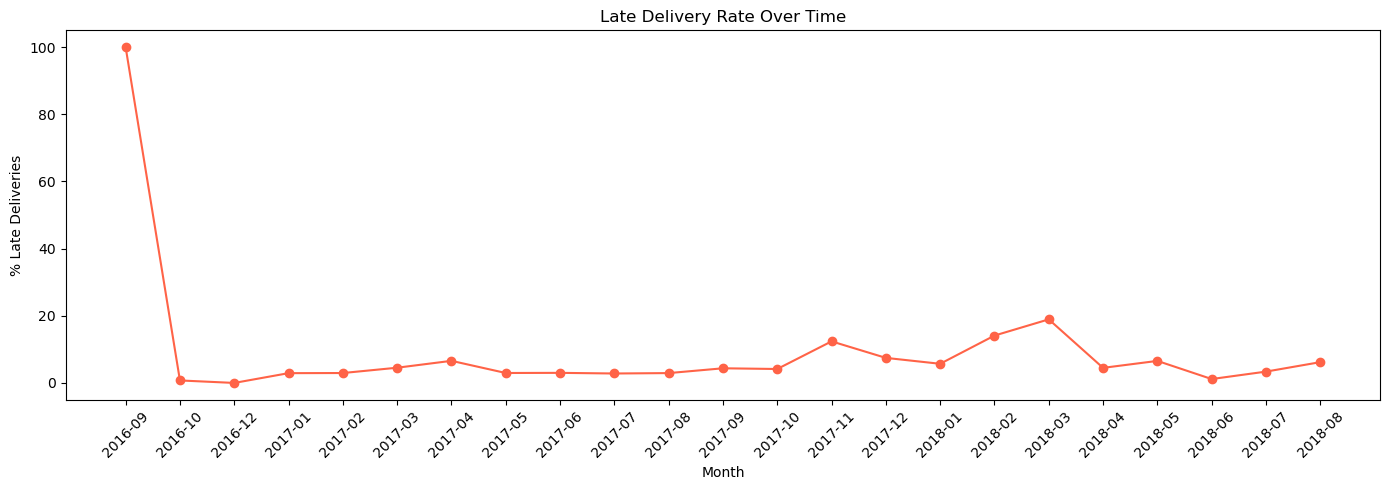

   purchase_month  total  late  late_pct
0         2016-09      1     1    100.00
17        2018-03   7041  1333     18.93
16        2018-02   6640   936     14.10
13        2017-11   7340   909     12.38
14        2017-12   5539   413      7.46


In [20]:
##Peak Late Delivery Periods: When during the year are delays worst

# Extract month from purchase date
master["order_purchase_timestamp"] = pd.to_datetime(master["order_purchase_timestamp"])
master["purchase_month"] = master["order_purchase_timestamp"].dt.to_period("M")

# Late orders by month
monthly = delivered.copy()
monthly["order_purchase_timestamp"] = pd.to_datetime(monthly["order_purchase_timestamp"])
monthly["purchase_month"] = monthly["order_purchase_timestamp"].dt.to_period("M")

monthly_stats = monthly.groupby("purchase_month").agg(
    total=("order_id", "count"),
    late=("delivery_status", lambda x: (x != "On Time").sum())
).reset_index()

monthly_stats["late_pct"] = (monthly_stats["late"] / monthly_stats["total"] * 100).round(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly_stats["purchase_month"].astype(str), monthly_stats["late_pct"], marker="o", color="tomato")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("% Late Deliveries")
plt.title("Late Delivery Rate Over Time")
plt.tight_layout()
plt.savefig("late_over_time.png")
plt.show()

print(monthly_stats.sort_values("late_pct", ascending=False).head(5))

In [25]:
# Export the main analysis data for the dashboard
delivered.to_csv("dashboard_data.csv", index=False)
state_stats.to_csv("state_stats.csv", index=False)
print("Export done!")

Export done!


In [26]:
# Export ALL orders including undelivered
master.to_csv("dashboard_data.csv", index=False)
print("Done! Shape:", master.shape)

Done! Shape: (99992, 21)
